## 演習：エピポーラ方程式

In [3]:
import math
import numpy as np
import matplotlib.pyplot as plt

### 復習：外積の応用

法線ベクトル（正規化前） [ 1 -1  0] , 法線ベクトル（単位ベクトル） [ 0.70710678 -0.70710678  0.        ]


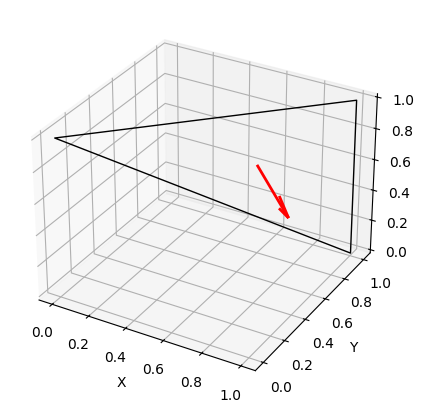

In [4]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 三角形ポリゴンの法線
x1 = np.array([0,0,1])
x2 = np.array([1,1,0])
x3 = np.array([1,1,1])

# 法線 (normal) の計算
v1 = x2 - x1
v2 = x3 - x1
normal = np.cross(v1, v2)
normal_length = np.linalg.norm(normal)
normal_unit = normal / normal_length  # 単位ベクトルに正規化

print('法線ベクトル（正規化前）', normal, ', 法線ベクトル（単位ベクトル）',normal_unit)

# 三角形の重心を計算
centroid = (x1 + x2 + x3) / 3

# 描画
fig = plt.figure(figsize=(5,5))
ax = fig.add_subplot(111, projection='3d')

# ポリゴンを描画
vertices = [x1, x2, x3]
polygon = Poly3DCollection([vertices], edgecolors='k', linewidths=1, alpha=0)
ax.add_collection3d(polygon)

# 法線ベクトルを矢印で描画（ベクトル場の表示関数）
ax.quiver(centroid[0], centroid[1], centroid[2],
          normal_unit[0], normal_unit[1], normal_unit[2],
          length=0.5, color='r', linewidth=2)

ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
plt.show()

## Epipolar Equation / Essential Matrix Exercise

このノートブックでは、2台のカメラと1つの3次元点を用いて、

- 左カメラ: $P_1 = [I \mid 0]$
- 右カメラ: $P_2 = [R \mid t]$

のもとで、3次元点 $X$ を各カメラの正規化画像座標に投影します。

そのうえで、

- $x_1$
- $R x_2$
- $t$

が同一平面上にあることを確認するため、
- essential matrix $E = [t]_\times R$ を算出、
- epipolar equation $x_2^\top E x_1 = 0$

を数値的に確かめましょう。

In [5]:
## 関数定義

def skew(v):
    """
    ベクトル v = [vx, vy, vz] に対して、
    [v]_x （外積行列）を返す。
    """
    vx, vy, vz = v
    return np.array([
        [0.0, -vz,  vy],
        [vz,   0.0, -vx],
        [-vy,  vx,   0.0]
    ])


def rotx(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [1, 0, 0],
        [0, c, -s],
        [0, s,  c]
    ], dtype=float)


def roty(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [ c, 0, s],
        [ 0, 1, 0],
        [-s, 0, c]
    ], dtype=float)


def rotz(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([
        [c, -s, 0],
        [s,  c, 0],
        [0,  0, 1]
    ], dtype=float)


def project_normalized(X_cam):
    """
    カメラ座標系での3次元点 X_cam = [X, Y, Z] を
    正規化画像座標の同次ベクトル x = [u, v, 1] にする。
    """
    X, Y, Z = X_cam
    return np.array([X / Z, Y / Z, 1.0], dtype=float)


def normalize_homogeneous(x):
    """
    同次ベクトルの最後を1にそろえる
    """
    return x / x[-1]

In [6]:
## カメラ設定

# 左カメラ: P1 = [I | 0]
R1 = np.eye(3)
t1 = np.zeros(3)

# 右カメラ: P2 = [R | t]
# 少し回転と並進を与える
R = rotz(np.deg2rad(10)) @ roty(np.deg2rad(15))
t = np.array([0.5, 0.1, 0.2], dtype=float)

print("R =\n", R)
print("t =", t)

R =
 [[ 0.95125124 -0.17364818  0.254887  ]
 [ 0.16773126  0.98480775  0.04494346]
 [-0.25881905  0.          0.96592583]]
t = [0.5 0.1 0.2]


In [7]:
## 3次元点を置く

# 左カメラ座標系での3次元点
X = np.array([0.3, -0.2, 2.0], dtype=float)

print("3D point X =", X)

3D point X = [ 0.3 -0.2  2. ]


In [8]:
## 各カメラへの投影

# 左カメラ座標
X1_cam = X

# 右カメラ座標
X2_cam = R @ X + t

print("X1_cam =", X1_cam)
print("X2_cam =", X2_cam)

# 正規化画像座標
x1 = project_normalized(X1_cam)
x2 = project_normalized(X2_cam)

print("x1 =", x1)
print("x2 =", x2)

X1_cam = [ 0.3 -0.2  2. ]
X2_cam = [1.32987901 0.04324474 2.05420594]
x1 = [ 0.15 -0.1   1.  ]
x2 = [0.64739323 0.0210518  1.        ]


## 課題：Essential matrixの計算と、方程式の確認

定義より、以下の空欄を埋めて、essential matrixを計算しましょう

In [9]:
## Essential matrix の計算（課題）

E = skew(t) @ R

print("Essential matrix E = [t]_x R =\n", E)

Essential matrix E = [t]_x R =
 [[-0.05942816 -0.19696155  0.08760389]
 [ 0.31965977 -0.03472964 -0.43198551]
 [-0.01125949  0.50976869 -0.00301697]]


In [10]:
## エピポーラ方程式が成り立つことの確認
epi_val = x2.T @ E @ x1
print("x2^T E x1 =", epi_val)

x2^T E x1 = 1.3877787807814457e-17


## 検算：外積と内積による計算

※計算誤差があるので、必ずしも上のセルとは一致しません

In [11]:
triple_product = x2 @ np.cross(t, R @ x1)
print("scalar triple product =", triple_product)

scalar triple product = 6.938893903907228e-18
